In [1]:
# 행렬을 이용한 내적연산 --> 벡터의 내적연산
# w1*x1 + w2*x2 + w3*x3 + b
# step function : 0보다 크면 1, 0보다 작으면 0
# 활성화 함수 : step function, sigmoid function, relu function
# 계단함수가 필요한 이유 : 비선형적인 행동을 해야지만 구역을 나누는 기준선(Decison Bounday)을 만들 수 있다.
# 활성화 함수가 없으면 아무리 층을 깊게 쌓아도 결국 y = wx  + b 형태의 선형함수 밖에 만들 수 없다.

In [ ]:
%conda install pytorch -c pytorch

In [4]:
import torch


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.5 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "c:\Users\Playdata\miniconda3\envs\test_env\lib\runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "c:\Users\Playdata\miniconda3\envs\test_env\lib\runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "c:\Users\Playdata\miniconda3\envs\test_env\lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "c:\Users\Playdata\miniconda3\envs\test_env\lib\site-packages\traitlets\config\application.py", line 1075, in launc

In [5]:
torch.__version__

'2.2.2'

In [24]:
# step function
def step_function(x):
    return (x >= 0).float() # 계산에 가면 float 형태로 많이 쓰이기 때문에

In [14]:
step_function(5)

1.0

In [34]:
# y = 0.5x1 + 0.5x2 - 0.7
import numpy as np
x = torch.tensor([
    (0.0, 0.0), (0.0,1.0), (1.0,0.0), (1.0,1.0)
])
w = torch.tensor([[0.5],[0.5]])
b = -0.7

# 배치행렬곱을 지원 (broadcasting 포함)
# (batch, n, m) 을 (batch, m, n)
z = torch.matmul(x,w) + b
# 계단 함수 통과 <- 결정 경계를 그릴 수 있음
output = step_function(z)
for x_val, out_val in zip(x, output):
    print(f'입력 {x_val} 출력 {out_val}') # end 연산 

입력 tensor([0., 0.]) 출력 tensor([0.])
입력 tensor([0., 1.]) 출력 tensor([0.])
입력 tensor([1., 0.]) 출력 tensor([0.])
입력 tensor([1., 1.]) 출력 tensor([1.])


xor : 입력이 서로 다를때만 1을 출력

In [35]:
# 임의로 가중치를 xor
w_xor = torch.tensor([[1.0], [1.0]])
b_xor = -0.5
print(f'가중치 w : {w_xor} b: {b_xor}')

z = torch.matmul(x,w_xor) + b_xor
output_xor = step_function(z)
for x_val, out_val in zip(x, output):
    corrent_target = int(x_val[0] != x_val[1])
    print(f'입력 {x_val} 출력 {out_val} 정답 {corrent_target} ')

가중치 w : tensor([[1.],
        [1.]]) b: -0.5
입력 tensor([0., 0.]) 출력 tensor([0.]) 정답 0 
입력 tensor([0., 1.]) 출력 tensor([0.]) 정답 1 
입력 tensor([1., 0.]) 출력 tensor([0.]) 정답 1 
입력 tensor([1., 1.]) 출력 tensor([1.]) 정답 0 


- 다층 퍼셉트론 : 은닉층 (hidden layer)
- 활성화 함수 : 시그모이드나 ReLU 같은 파생 활성화 함수

In [ ]:
# x = [1.0, 0.0]
# z1 = w11 * x1 + w21 * x2 + b1
# z2 = w12 * x1 + w22 * x2 + b1
# ...
# z = x*w + b

# z의 값에 활성화 함수 시그모이드 씌우면 - 값이 아무리 크기가 작아도 0-1 사이로 압출
# 직선이였던 데이터 공간이 곡면으로 휘어짐

# x
# z = xw + b
# h = sigmoid(z)
# z2 = hw2 + b2
# y = sigmoid(z2)
# 최종 예측 y


# 입력 2 / 은닉층 2개 뉴런 / 출력 1개의 뉴런
# x = [1.0, 0.0]
# w1 = [
#    20, -20
#    20, -20
# ]
# b = [ -10, 20]
# w2 = [ 20
#        20
#      ]
# b2 = [-30]
# 은닉층 선형 결합
# z = [1.0, 0.0] @ [20 -20         + [-10, 30]  =  [10, 10]
#                   20 -20]
# 시그모이드 [ 0.9999, 0.9999 ]
# 출력층 결합 [ 0.999, 0.999 ] @ [20
#                               20]  + (-30) = 39.998 - 30 = 9.998
#
# 출력 활성화 시그모이드(9.998) = 0.999999 판정 1

In [ ]:
# 활성화 함수의 필요성 선형붕괴(활성화 함수 없이 층을 쌓으면 의미가 없다.)
# 1층 h = w1 * x + b1
# 2층 y = w2 * h + b2 = w2(w1 * x + b1) + b2 
# w2*w1*x + w2*b1 + b2 
# W' = w2w1 b' = w2b1 + b2
# y = W'x + b'

# 활성화 함수는 공간변형 도구 
# 계단함수는 판단은 가능하지만 학습은 불가능(미분 불가능, 기울기 알 수 없음, 기울기 0)

In [40]:
import torch
torch.sigmoid(torch.tensor(-5))

tensor(0.0067)

$
\sigma(x) = \frac{1}{1 + e^{-x}}
$
# 
$
\sigma'(x) = \sigma(x)\left(1 - \sigma(x)\right)
$

In [ ]:
# x    시그모이드      시그모이드 미분
# 0      0.5           0.25   가장 활발하게 학습
# +-2  0.88/0.12     0.10   학습속도 둔화
# +-5  0.99/0.01     0.0067  거의 학습이 안됨
# +-10   1/0           0     완전정지(뉴런 사망)

In [48]:
# torch 자동미분 기능
import torch
x = torch.tensor([0.0], requires_grad=True)
y = torch.sigmoid(x)
y.backward()
print(x.grad)

tensor([0.2500])


In [50]:
# ReLU
# f(x) = z = max(0,x)
import numpy as np
x = np.array([-5,0,2,6,-5])
np.maximum(0,x)

array([0, 0, 2, 6, 0])

In [ ]:
# ReLU는 미분을 하면 양수구간은 항상 1
# 1*1*1*1 = 1 기울기가 죽지 않고 끝까지 전달
# 입력이 음수면 기울기가 0 출력이 비활성화 -> 계산중에 불필요한 뉴런을 제거하는 효과
# 시그모이드보다 6배이상 빠르고 안정적으로 학습이 가능

In [51]:
# 활성화 없이 100층 = 선형 붕괴
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
torch.manual_seed(42)

In [52]:
# 케라스
%pip install tensorflow

   ---------------------------------------- 0.0/350.6 MB ? eta -:--:--
   ---------------------------------------- 3.9/350.6 MB 18.1 MB/s eta 0:00:20
   -- ------------------------------------- 20.2/350.6 MB 47.2 MB/s eta 0:00:07
   ---- ----------------------------------- 38.0/350.6 MB 58.9 MB/s eta 0:00:06
   ------ --------------------------------- 56.9/350.6 MB 65.8 MB/s eta 0:00:05
   ------- -------------------------------- 66.3/350.6 MB 64.0 MB/s eta 0:00:05
   ------- -------------------------------- 69.7/350.6 MB 55.6 MB/s eta 0:00:06
   -------- ------------------------------- 73.7/350.6 MB 50.5 MB/s eta 0:00:06
   -------- ------------------------------- 74.4/350.6 MB 43.6 MB/s eta 0:00:07
   --------- ------------------------------ 81.8/350.6 MB 43.1 MB/s eta 0:00:07
   ---------- ----------------------------- 91.2/350.6 MB 42.8 MB/s eta 0:00:07
   ----------- --------------------------- 107.7/350.6 MB 46.2 MB/s eta 0:00:06
   ------------- ------------------------- 124.0/3

In [53]:
import tensorflow as tf
fasion_minst = tf.keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [55]:
(x_train_full, y_train_full), (x_test,y_test) = fasion_minst
x_train_full.shape, x_test.shape

((60000, 28, 28), (10000, 28, 28))

In [57]:
x_train, y_train = x_train_full[:-5000] , y_train_full[:-5000]
x_valid, y_valid = x_train_full[-5000:], y_train_full[-5000:]
x_train.shape, x_valid.shape

((55000, 28, 28), (5000, 28, 28))

In [ ]:
x_train, x_valid, x_test = x_train / 255. , x_valid / 255. , x_test / 255. # 255로 나누면  0~1 로 바뀐다. (학습이 안정화 됨)

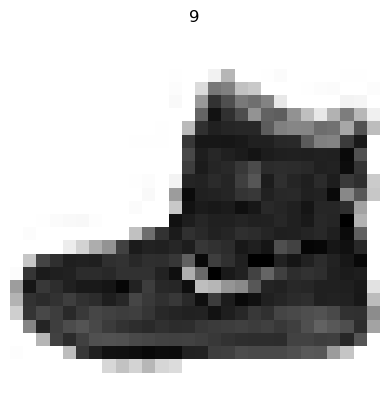

In [64]:
import matplotlib.pyplot as plt
plt.imshow(x_train[0], cmap='binary')
plt.axis('off')
plt.title(y_train[0])
plt.show()

In [65]:
np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [ ]:
# 다중 분류 (multi class, 단일 정답)
# 마지막 출력층 softmax = 모든 출력의 합이 1, 확률 분포 형태
# 각 클래스별로 확률 값
import tensorflow as tf
tf.random.set_seed(42)
model = tf.keras.Sequential()
model.add(tf.keras.layers.Input(shape=(28,28)))
model.add(tf.keras.layers.Flatten()) # 1차원으로 만들어줌
model.add(tf.keras.layers.Dense(300, activation='relu')) # 300개 뉴런을 출력
model.add(tf.keras.layers.Dense(100, activation='relu'))
model.add(tf.keras.layers.Dense(10, activation='softmax')) # 마지막 확률분포, 0일때 확률을 나타냄

In [67]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [71]:
784*300+ 300

235500

In [72]:
# 컴파일
model.compile(
    loss = 'sparse_categorical_crossentropy', # 모델이 얼마나 틀렸는지 숫자로 계산
    optimizer = 'sgd', 
    metrics = ['accuracy'] # 모델 성능을 사람이 보기 쉽게 알려줌
)

In [ ]:
history = model.fit(x_train, y_train, epochs=30, validation_data=(x_valid, y_valid)) # 학습을 하면서 과적합 여부 확인
# 학습 할수록 accuracy 높고 val_accuracy 낮아진다. 과적합 
# 가장 낮은 순간의 epoch를 찾아야 함

Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7675 - loss: 0.7058 - val_accuracy: 0.8276 - val_loss: 0.5058
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8320 - loss: 0.4883 - val_accuracy: 0.8408 - val_loss: 0.4551
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8473 - loss: 0.4432 - val_accuracy: 0.8470 - val_loss: 0.4308
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8555 - loss: 0.4149 - val_accuracy: 0.8510 - val_loss: 0.4158
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8623 - loss: 0.3941 - val_accuracy: 0.8560 - val_loss: 0.4035
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8676 - loss: 0.3777 - val_accuracy: 0.8574 - val_loss: 0.3944
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8718 - loss: 0.3640 - val_accuracy: 0.8594 - val_loss: 0.3879
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8756 - loss: 0.3524 - 

In [89]:
predict = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 914us/step


In [86]:
np.argmax(predict, axis=1)

array([9, 2, 1, 1, 6])

In [87]:
y_test[:5]

array([9, 2, 1, 1, 6], dtype=uint8)

In [90]:
sum(np.argmax(predict, axis=1) == y_test) / len(y_test)

np.float64(0.8754)

In [92]:
from sklearn.metrics import classification_report
print(classification_report(y_test, np.argmax(predict, axis=1))) # 가장 높은 값을 갖는 것에 확률

              precision    recall  f1-score   support

           0       0.85      0.81      0.83      1000
           1       0.99      0.97      0.98      1000
           2       0.74      0.86      0.80      1000
           3       0.81      0.93      0.87      1000
           4       0.83      0.77      0.80      1000
           5       0.88      0.98      0.93      1000
           6       0.78      0.63      0.69      1000
           7       0.95      0.90      0.93      1000
           8       0.96      0.96      0.96      1000
           9       0.98      0.94      0.96      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.87     10000
weighted avg       0.88      0.88      0.87     10000



In [95]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

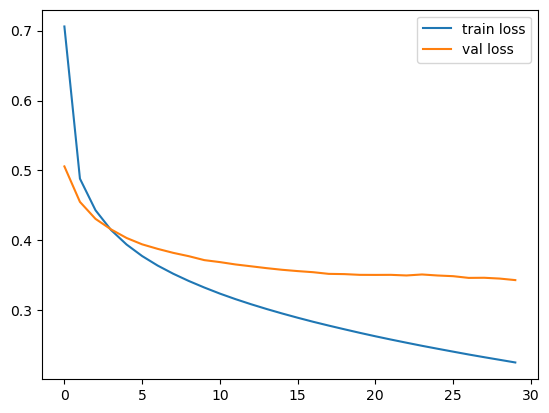

In [ ]:
# x축은 range(30)
# y축은 loss, val_loss
# plt.plot
x = range(30)

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.plot(x, loss, label='train loss')
plt.plot(x,val_loss, label='val loss')
plt.legend()
plt.show()
# 점점 가면 과적합이 생길 것 같다.(예상)